In [13]:
# !git clone https://github.com/milabuob/nirfaster-FF.git
!wget -c https://github.com/JiamingCao/nirfast-atlas/raw/refs/heads/main/Conte69_on_TT_32k.mat
!wget -c https://github.com/JiamingCao/nirfast-atlas/raw/refs/heads/main/IM_Gordon_2014_333_Parcels.mat
!wget -c https://github.com/JiamingCao/nirfast-atlas/raw/refs/heads/main/headvol.mat
!wget -c https://github.com/JiamingCao/nirfast-atlas/raw/refs/heads/main/headvol_optodes.mat
!wget -c https://github.com/milabuob/nirfaster-FF/releases/download/v1.3.0/cpu-linux-python312.zip
!wget -c https://github.com/milabuob/nirfaster-FF/releases/download/v1.3.0/gpu-linux-python312.zip
!unzip cpu-linux-python312.zip -d nirfaster-FF/nirfasterff/lib
!unzip gpu-linux-python312.zip -d nirfaster-FF/nirfasterff/lib
!rm cpu-linux-python312.zip gpu-linux-python312.zip

--2026-09-28 18:09:43--  https://github.com/JiamingCao/nirfast-atlas/raw/refs/heads/main/Conte69_on_TT_32k.mat
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/JiamingCao/nirfast-atlas/refs/heads/main/Conte69_on_TT_32k.mat [following]
--2026-09-28 18:09:43--  https://raw.githubusercontent.com/JiamingCao/nirfast-atlas/refs/heads/main/Conte69_on_TT_32k.mat
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4071598 (3.9M) [application/octet-stream]
Saving to: ‘Conte69_on_TT_32k.mat’

Conte69_on_TT_32k.m 100%[===================>]   3.88M   769KB/s    in 5.2s    

2026-09-28 18:09:49 (769 KB/s) - ‘C

In [1]:
import sys
# sys.path.insert(1, '/Users/hamiddehghani/nirfaster-FF-main/')
sys.path.insert(1, 'nirfaster-FF/')
import nirfasterff as ff # ff is short for fast and furious
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import copy
import math


In [14]:
# load the 3D volume
# Note that the data type must be uint8
vol = sio.loadmat('headvol.mat')['mask']
# Load the optode information. This is the example 24x28 pad in NeuroDOT
tmp = sio.loadmat('headvol_optodes.mat')
link = tmp['link']
srcpos = tmp['srcpos']
detpos = tmp['detpos']

In [15]:
# define the parameters for the mesh and the optodes
params = ff.utils.MeshingParams()
params.offset = np.array([-87., -124.,  -76.5])
params.facet_distance = 10
params.facet_size = 10
params.smooth = False
# params.general_cell_size = 1.4

# params.subdomain = np.array([[1, 1.5],
#                             [3, 1.5],
#                             [5, 1.5]])

# optical property at 850nm
# 1: csf; 2: white; 3: gray; 4: bone; 5: skin
optical_props = np.array([[1, 0.004, 0.3, 1.4],
                [2, 0.0208, 1.0107, 1.4],
                [3, 0.0192, 0.6726, 1.4],
                 [4, 0.0139, 0.84, 1.4],
                 [5, 0.0190, 0.64, 1.4]])

# optodes
sources = ff.base.optode(srcpos)
detectors = ff.base.optode(detpos)

# create the mesh
mesh = ff.base.stndmesh()
mesh.from_volume(vol, param=params, prop=optical_props, src=sources, det=detectors, link=link)

Running CGAL mesher
Meshing...
Running local optimization...
Converting to NIRFAST format


In [16]:
mesh.nodes.shape

(111234, 3)

In [17]:
mesh.save_nirfast('headmesh')

In [2]:
mesh = ff.base.stndmesh()
mesh.from_file('headmesh')
# mesh.touch_optodes()

Sources integration functions loaded
Detectors integration functions loaded


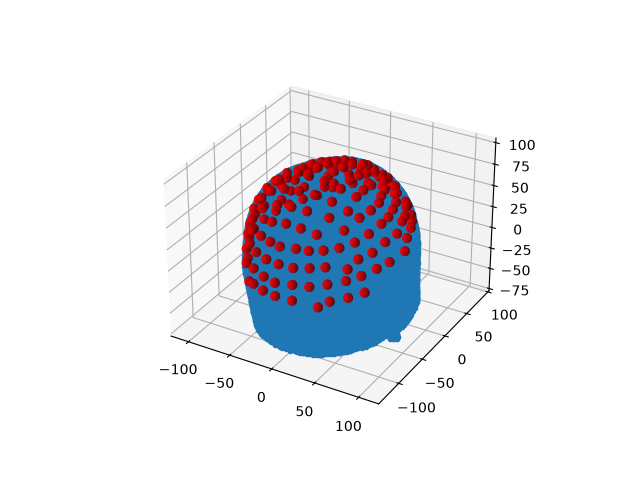

In [3]:
bndvtx = np.where(mesh.bndvtx==1)

%matplotlib widget
fig = plt.figure()
ax = plt.axes(projection='3d')

ax.plot3D(mesh.nodes[bndvtx,0],mesh.nodes[bndvtx,1],mesh.nodes[bndvtx,2],'.')
# create some little spheres for better visibility: matplotlib does not have true 3D markers
u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
xs = np.cos(u) * np.sin(v)
ys = np.sin(u) * np.sin(v)
zs = np.cos(v)
ri = 5

# fig, ax = ff.visualize.plot3dmesh(mesh)
# ax.plot3D(mesh.source.coord[:,0],mesh.source.coord[:,1],mesh.source.coord[:,2],'ro')
for xi, yi, zi in mesh.source.coord:
    ax.plot_surface(xi + ri * xs, yi + ri * ys, zi + ri * zs, color='red', edgecolor='None', alpha=0.9)

plt.axis('equal')
plt.show()

In [4]:
# plt.close('all')

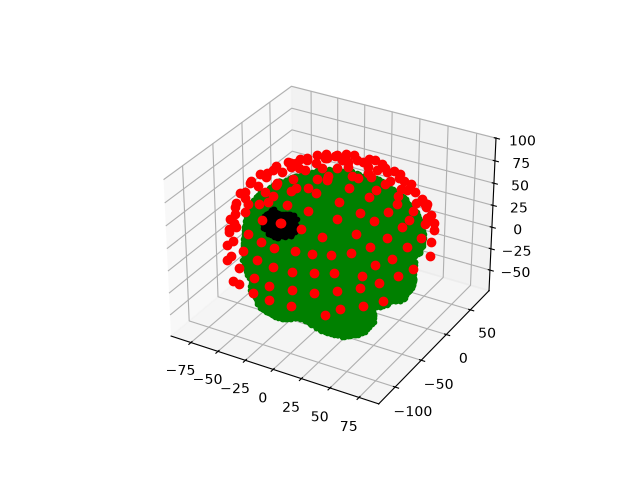

In [5]:

# 1. Load datasets
# The Cortical Area Parcellation from Resting-State Correlations dataset consists of 333 cortical patches segmented using resting-state fMRI (Gordon 2014).
gordon = sio.loadmat("IM_Gordon_2014_333_Parcels.mat")
# surface atlas constructed by David Van Essen's group, derived from structural MRI scans of 69 healthy control subjects. 
# It serves as a standard reference space for comparing cortical geometries across different people
# we use the nodal coordinates
conte = sio.loadmat("Conte69_on_TT_32k.mat") 

# 2. Get parcel ID
# 'Auditory','CinguloOperc','CinguloParietal','Default','DorsalAttn','FrontoParietal','None','RetrosplenialTemporal','SMhand','SMmouth','Salience','VentralAttn','Visual'
parcel = "Auditory"
side = "left"
size = 15

im = gordon["IM"][0, 0]
parcel_nets = gordon["Parcel_Nets"][0, 0]
im_nets = im["Nets"].flatten()
keep_idx = np.where(im_nets == parcel)[0] + 1  # +1 matches MATLAB 1-based indexing

# 3. Locate matching brain surface node coordinates
if side == "left":
    ctx_data = parcel_nets["CtxL"].flatten()
    ctx_nodes = conte["Anat"]["CtxL"][0, 0]["nodes"][0, 0]
elif side == "right":
    ctx_data = parcel_nets["CtxR"].flatten()
    ctx_nodes = conte["Anat"]["CtxR"][0, 0]["nodes"][0, 0]

matching_indices = np.where(np.isin(ctx_data, keep_idx))[0]

gray = np.where(mesh.region==3)

# compute the final mean coordinate vector and get distance of all nodes from that point
result_mean = ctx_nodes[matching_indices, :].mean(axis=0)
result = np.linalg.norm(mesh.nodes-result_mean,axis=1)

# get parcel index
ind = np.where(result <= size)[0]
parcel_indx = np.intersect1d(gray, ind)

%matplotlib widget
fig = plt.figure()
ax = plt.axes(projection='3d')

ax.plot3D(mesh.nodes[gray,0],mesh.nodes[gray,1],mesh.nodes[gray,2],'g.')
ax.plot3D(mesh.nodes[parcel_indx,0],mesh.nodes[parcel_indx,1],mesh.nodes[parcel_indx,2],'k.')
ax.plot3D(result_mean[0],result_mean[1],result_mean[2],'ro')

ax.plot3D(mesh.source.coord[:,0],mesh.source.coord[:,1],mesh.source.coord[:,2],'ro')


In [6]:
# we need to do the same in voxel space. Support we use a 3mm resolution grid,
mesh.voxelize(3)
# get the coordinates
X, Y, Z = np.meshgrid(mesh.vol.xgrid, mesh.vol.ygrid, mesh.vol.zgrid)
coords = np.c_[X.flatten('F'), Y.flatten('F'), Z.flatten('F')]
print(coords.shape)

(240720, 3)


In [7]:
# convert region label to voxel space
regions_vol = mesh.nntogrid('region').flatten('F')
print(regions_vol.shape)

(240720,)


In [8]:
# distance between the voxels and the center of brain region
grayvol = np.where(regions_vol==3)
distvol = np.linalg.norm(coords - result_mean, axis=1)
indvol = np.where(distvol <= size)[0]
parcel_indxvol = np.intersect1d(grayvol, indvol)

# visualize
vol2 = np.zeros(regions_vol.shape)
vol2[grayvol] = 1
vol2[parcel_indxvol] = 2
mesh.plotvol(vol2, bnd=1)

In [9]:
from scipy.special import gamma
def canonicalHRF(duration, Fs, peakTime=6., uShootTime=16., peakDisp=1.,
                 uShootDisp=1., ratio=1/6):
    # canonical hrf function adapted from nirs-toolbox, using standard SPM parameters
    t = np.arange(0, duration, 1/Fs)
    a1 = peakTime
    a2 = uShootTime
    b1 = peakDisp
    b2 = uShootDisp
    c  = ratio
    h = (b1**a1) * t**(a1-1)*np.exp(-b1*t)/gamma(a1) - c*(b2**a2)*(t**(a2-1))*np.exp(-b2*t)/gamma(a2)
    return h/h.max()

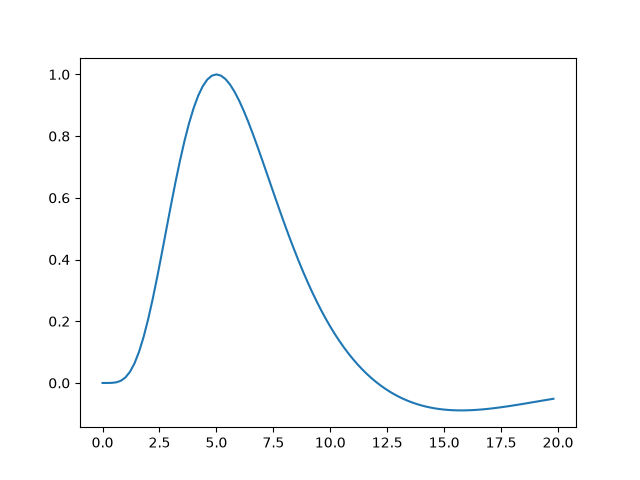

In [10]:
hrf_length = 20 #sec
Fs = 5.0 # hz
hrf = canonicalHRF(hrf_length, Fs)
tvec = np.arange(0, hrf_length, 1/Fs)
plt.close('all')
plt.plot(tvec, hrf)
plt.show()

In [11]:
# calculate the Jacobian matrix
J = mesh.jacobian(0)[0]

Calculating direct field...
Calculating adjoint field...
Integrating...


In [28]:
# visualize one of the bananas
mesh.plotvol(J[5,:], bnd=1)

In [12]:
# perturbation, but only the red voxels
# let's say the max change is 0.01
nchannels, nvoxels = J.shape
dmua = np.zeros((nvoxels, tvec.size))
dmua[parcel_indxvol,:] = hrf*0.01
dOD = J @ dmua

In [12]:
print(nchannels)

3478


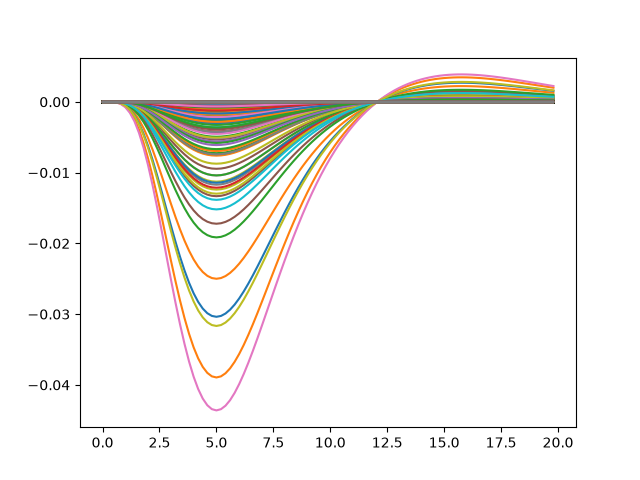

In [13]:
plt.close('all')
plt.plot(tvec, dOD.T)
plt.show()

In [14]:
# a very simple reconstruction at the peak, NeuroDOT-style regularization
alpha = 0.01
beta = 0.1
L = np.sqrt(alpha*(np.sum(J**2, axis=0)+beta))
recon = ff.inverse.tikhonov(J, L, dOD[:,25])
reconvol = np.reshape(recon, (mesh.vol.xgrid.size, mesh.vol.ygrid.size, mesh.vol.zgrid.size), order='F')

In [15]:
# intersect with gray matter and visualize
recon2 = np.zeros(recon.shape)
recon2[grayvol] = recon[grayvol]
mesh.plotvol(recon2, bnd=1)

In [27]:
# alternatively
recon2 = np.zeros(recon.shape)
recon2[grayvol] = 1
recon2[(regions_vol==3) & (recon>0.5*np.max(recon))] = 2
mesh.plotvol(recon2, bnd=1)